<a href="https://colab.research.google.com/github/nikhilgangrade1605/placement_predictor_demo/blob/main/placement_predictor_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(100, 4)

In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
import matplotlib.pyplot as plt

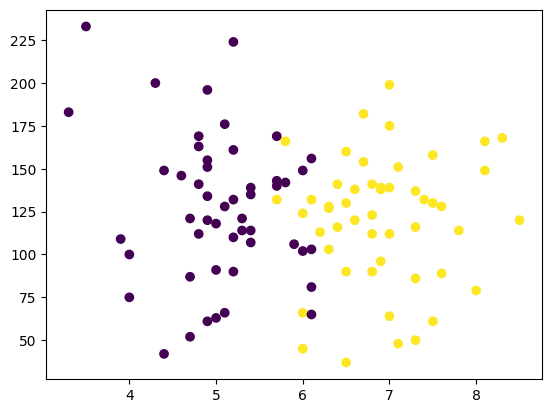

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,cgpa,iq
25,5.0,91.0
54,6.4,141.0
24,4.7,121.0
59,4.8,112.0
68,4.0,75.0
...,...,...
52,7.0,175.0
55,7.8,114.0
81,5.4,107.0
51,4.8,141.0


In [ ]:
y_train

,placement
25,0
54,1
24,0
59,0
68,0
...,...
52,1
55,1
81,0
51,0


In [ ]:
x_test

,cgpa,iq
30,7.6,128.0
8,6.1,156.0
37,8.1,149.0
41,5.4,114.0
33,6.0,149.0
35,6.8,90.0
39,4.6,146.0
58,8.0,79.0
96,4.4,42.0
12,5.4,139.0


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
from numpy.random import standard_cauchy


In [ ]:
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-8.61597064e-01, -8.23891849e-01],
       [ 3.90550918e-01,  4.21912358e-01],
       [-1.12991449e+00, -7.64093247e-02],
       [-1.04047535e+00, -3.00654082e-01],
       [-1.75598848e+00, -1.22254919e+00],
       [-8.61597064e-01, -1.52154220e+00],
       [ 9.27185768e-01,  1.86704524e+00],
       [ 5.69429202e-01, -1.01325409e-01],
       [ 3.01111777e-01, -5.24898839e-01],
       [-1.12991449e+00, -9.23556185e-01],
       [ 1.22233494e-01, -1.47171004e+00],
       [ 3.27943519e-02, -1.97003172e+00],
       [ 3.01111777e-01,  9.80032643e-02],
       [ 1.19550319e+00, -2.00989745e-01],
       [ 1.22233494e-01, -5.24898839e-01],
       [-9.51036206e-01, -1.01325409e-01],
       [-7.72157923e-01,  1.29397530e+00],
       [ 2.08989461e+00,  1.09464663e+00],
       [ 9.27185768e-01,  3.72080190e-01],
       [-1.12991449e+00, -1.79561913e+00],
       [ 7.48307485e-01, -3.00654082e-01],
       [ 2.11672635e-01, -2.75737998e-01],
       [-5.93279639e-01, -2.50821914e-01],
       [-5.

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
y_test

,placement
30,1
8,0
37,1
41,0
33,0
35,1
39,0
58,1
96,0
12,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

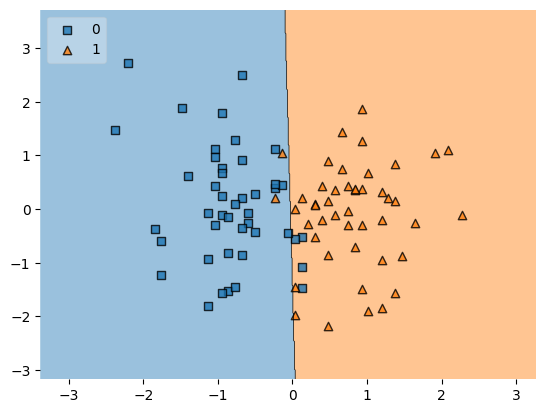

In [ ]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)